# AgroLab Analytics — Metodología CRISP-DM
## Pipeline Completo: Data Profiling, ETL Robusto, EDA y Prototipado Analítico
**Dataset de Origen:** `data/raw/BD_lab_28-8-26.xlsx` (Hoja `Export`)  
**Entorno de Producción:** AgroLab Dashboard (`Streamlit` + `Plotly` + `Pandas`)  

---

### Visión General del Proyecto y Metodología CRISP-DM
Este notebook implementa y documenta de forma integral y reproducible el ciclo de vida **CRISP-DM (Cross-Industry Standard Process for Data Mining)** aplicado a la analítica de demanda, cultivos y cartera de clientes del laboratorio agrícola:

```mermaid
flowchart LR
    P1["1. Business Understanding"] --> P2["2. Data Understanding & Profiling"]
    P2 --> P3["3. Pipeline ETL"]
    P3 --> P4["4. EDA Multivariado"]
    P4 --> P5["5. Prototipos HU-01, HU-02, HU-03"]
    P5 --> P6["6. Evaluación & Salidas RD-02"]
```

#### Objetivos del Negocio y Mapeo de Historias de Usuario
1. **Objetivo 1 & HU-01 (RF-01): Identificación de Clientes Frecuentes & Alerta de Churn Estacional**
   - Ranking de clientes ordenado por volumen de muestras de forma descendente.
   - Filtros dinámicos por período de fechas, especie de cultivo y **estado del cliente (activo/inactivo)**.
   - Detección visual de **Churn Estacional**: clientes cuyo volumen en el período/mes actual sea **0%** respecto a su promedio histórico para la misma época del año.
2. **Objetivo 2 & HU-02 (RF-02): Reporte de Cultivo por Especie y Período**
   - Resumen métrico KPI acumulado con coincidencia exacta con la suma de tablas.
   - Distribución de demanda por especie limitando a las **10 principales y agrupando las restantes en "Otras"** (Ley de Pareto).
   - Identificación de intervalos críticos de demanda por cultivo y tipo de análisis.
3. **Objetivo 3 & HU-02 (RF-03): Evolución Mensual y Alertas de Capacidad**
   - Serie cronológica continua de muestras para **Trigo y Soja** (curva continua sin baches/gaps temporales).
   - Sistema de alertas de saturación operativa mensual al **75% (Advertencia)** y **90% (Saturación)** del volumen crítico.
4. **Objetivo 4 & HU-03 (RF-04): Segmentación RFM y Alerta de Fuga de Clientes**
   - Scoring RFM por quintiles de 3 dígitos (**111 al 555**) evaluado sobre el ciclo agrícola 25/26 o período general.
   - Detección automática y priorización comercial de cuentas **"En Riesgo"**: baja Recencia ($R \le 2$) con alta Frecuencia o Valor histórico ($F \ge 4 \lor M \ge 4$).

---
## Fase 1: Comprensión del Negocio (Business Understanding)

### Contexto de Operaciones del Laboratorio Agronómico
El laboratorio presta servicios analíticos de calidad de semillas y granos (ensayos de poder germinativo, viabilidad por tetrazolio, pureza físico-botánica, sanidad, peso de mil granos, etc.).
Las dinámicas de la demanda presentan particularidades agronómicas clave:
- **Estacionalidad de Campañas Agrícolas**:
  - **Cosecha Fina (Trigo, Cebada)**: Picos de ingreso y análisis concentrados entre mayo-julio (siembra) y noviembre-enero (cosecha).
  - **Cosecha Gruesa (Soja, Maíz, Maní, Girasol)**: Picos de ingreso concentrados entre febrero-junio.
- **Tipología de Clientes**:
  - **Productores y Semilleros Particulares**: Clientes individuales recurrentes (`id_cliente <= 50.000`).
  - **Cuentas de Convenio Institucional / Campañas Especiales**: Acuerdos corporativos identificados con `id_cliente > 50.000` (se analizan en volumen global pero se excluyen de la segmentación RFM individual).
- **Riesgo de Churn Estacional**:
  - Dado el ciclo anual de los cultivos, un cliente que no envía muestras en un mes de baja demanda no necesariamente ha abandonado el laboratorio. El verdadero síntoma de fuga ocurre cuando un cliente que habitualmente enviaba muestras en una época específica (ej. Trigo en junio) envía **0 muestras** en ese mismo mes en la campaña actual.

---
## Fase 2: Comprensión de los Datos & Profiling (Data Understanding)
En esta fase se audita exhaustivamente el archivo en bruto `data/raw/BD_lab_28-8-26.xlsx` para caracterizar tipos de datos, cardinalidad, valores nulos, registros duplicados y anomalías estructurales.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "sans-serif"

# Ruta del archivo sin procesar
raw_path = os.path.join("..", "data", "raw", "BD_lab_28-8-26.xlsx")
if not os.path.exists(raw_path):
    raw_path = os.path.join("data", "raw", "BD_lab_28-8-26.xlsx")

df_raw = pd.read_excel(raw_path, sheet_name=0)
print(f"Dimensiones en bruto: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print("\nColumnas detectadas en bruto:")
for c in df_raw.columns:
    print(f" - {repr(c)}")


Dimensiones en bruto: 8157 filas x 15 columnas

Columnas detectadas en bruto:
 - 'Fecha Ing Muestra'
 - 'Muestra'
 - 'Carta Camara'
 - 'Fecha de Certificacion'
 - 'Certificado'
 - 'Fecha Factura'
 - 'PtoVta'
 - 'Letra'
 - 'Numero Factura'
 - 'Id'
 - 'Razón Social'
 - 'Laboratorios'
 - 'Tipo analisis'
 - 'Especies'
 - 'Importe Solicitud'


### Auditoría de Calidad: Filas Footer, Duplicados y Tipos Mixtos
1. **Filas de pie de página (Footer Metadata)**: El archivo exportado incluye notas y textos al pie de página (ej. fila 8156: *"Filtros aplicados: Area es Semillas..."* y fila 8155 vacía).
2. **Duplicados en Clave Primaria `Muestra`**: Se audita si existen muestras repetidas y las diferencias entre sus registros.
3. **Tipos mixtos en Fechas**: `Fecha Ing Muestra` contiene mezcla de `datetime` y `float` debido a las filas footer.

In [2]:
print("--- ÚLTIMAS 4 FILAS DEL EXCEL (DETECCIÓN DE FOOTER) ---")
display(df_raw.tail(4))

# Detección de duplicados en clave 'Muestra'
valid_samples = df_raw.dropna(subset=["Muestra"])
duplicated_mask = valid_samples.duplicated(subset=["Muestra"], keep=False)
duplicates_df = valid_samples[duplicated_mask].sort_values("Muestra")

print(f"\nTotal de muestras únicas: {valid_samples['Muestra'].nunique()}")
print(f"Registros duplicados de 'Muestra': {valid_samples['Muestra'].duplicated().sum()}")
print("\nDetalle de registros duplicados detectados:")
display(duplicates_df[["Fecha Ing Muestra", "Muestra", "Id", "Especies", "Importe Solicitud", "Numero Factura"]])


--- ÚLTIMAS 4 FILAS DEL EXCEL (DETECCIÓN DE FOOTER) ---


,Fecha Ing Muestra,Muestra,Carta Camara,Fecha de Certificacion,Certificado,Fecha Factura,PtoVta,Letra,Numero Factura,Id,Razón Social,Laboratorios,Tipo analisis,Especies,Importe Solicitud
8153,2026-08-21 00:00:00,435783.0,2244.0,2026-08-28,8430.0,2026-08-31,4.0,FA,5016.0,3659.0,NN,Semillas,Fuerza Total,Poroto,87000.0
8154,2026-08-28 00:00:00,435974.0,2244.0,2026-08-28,8434.0,2026-08-31,4.0,FA,5016.0,3659.0,NN,Semillas,Poroto Adzuki,Poroto Adzuki,87000.0
8155,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8156,Filtros aplicados: \nArea es Semillas\nFecha F...,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Total de muestras únicas: 8150
Registros duplicados de 'Muestra': 5

Detalle de registros duplicados detectados:


,Fecha Ing Muestra,Muestra,Id,Especies,Importe Solicitud,Numero Factura
1905,2021-10-07 00:00:00,378689.0,4921.0,Soja,3700.0,1462.0
1906,2021-10-07 00:00:00,378689.0,4920.0,Soja,3700.0,1556.0
1908,2021-10-07 00:00:00,378691.0,4921.0,Soja,4200.0,1462.0
1909,2021-10-07 00:00:00,378691.0,4920.0,Soja,4200.0,1556.0
3261,2022-12-07 00:00:00,389801.0,392.0,Soja,7900.0,2293.0
3262,2022-12-07 00:00:00,389801.0,392.0,Soja,7900.0,2293.0
3643,2023-05-04 00:00:00,397018.0,4715.0,Soja,19000.0,2517.0
3644,2023-05-04 00:00:00,397018.0,4715.0,Soja,19000.0,2537.0
7881,2026-06-23 00:00:00,433933.0,3660.0,Soja,77000.0,4883.0
7882,2026-06-23 00:00:00,433933.0,6006.0,Soja,77000.0,4947.0


---
## Fase 3: Preparación de Datos & Pipeline ETL (Data Preparation)

En esta fase se implementa el pipeline ETL determinístico y robusto:
1. **Normalización de Nombres**: Conversión de nombres con tildes y espacios a estándar `snake_case` según `DATA_DICTIONARY.md`.
2. **Poda Defensiva**: Eliminación de filas footer y registros sin identificador `Muestra` o `Id`.
3. **Deduplicación Estricta**: Conservación de la versión más reciente por `id_muestra` (`keep='last'`).
4. **Tipado Estricto**:
   - `id_muestra` e `id_cliente` $\rightarrow$ `int64`
   - `fecha_ing_muestra`, `fecha_de_certificacion`, `fecha_factura` $\rightarrow$ `datetime64[ns]`
   - `importe_solicitud` $\rightarrow$ `float64` (limpieza de símbolos y espacios)
5. **Carga Protegida (Load)**: Exportación del dataset limpio a `data/processed/cleaned_agro_data.csv`.

In [3]:
COLUMN_RENAME_MAP = {
    "Fecha Ing Muestra": "fecha_ing_muestra",
    "Muestra": "id_muestra",
    "Carta Camara": "carta_camara",
    "Fecha de Certificacion": "fecha_de_certificacion",
    "Certificado": "certificado",
    "Fecha Factura": "fecha_factura",
    "PtoVta": "ptovta",
    "Letra": "letra",
    "Numero Factura": "numero_factura",
    "Id": "id_cliente",
    "Razn Social": "razon_social",
    "Razón Social": "razon_social",
    "Laboratorios": "laboratorios",
    "Tipo analisis": "tipo_analisis",
    "Especies": "especies",
    "Importe Solicitud": "importe_solicitud",
}

def run_etl_pipeline(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()
    
    # 1. Renombrar columnas
    df = df.rename(columns=COLUMN_RENAME_MAP)
    
    # 2. Filtrar filas nulas en identificadores clave (elimina footers)
    initial_rows = len(df)
    df = df.dropna(subset=["id_muestra", "id_cliente"]).reset_index(drop=True)
    footer_removed = initial_rows - len(df)
    
    # 3. Deduplicación por id_muestra conservando la última versión
    pre_dedup = len(df)
    df = df.drop_duplicates(subset=["id_muestra"], keep="last").reset_index(drop=True)
    duplicates_removed = pre_dedup - len(df)
    
    # 4. Parseo y tipado
    df["id_muestra"] = df["id_muestra"].astype("int64")
    df["id_cliente"] = df["id_cliente"].astype("int64")
    
    date_cols = ["fecha_ing_muestra", "fecha_de_certificacion", "fecha_factura"]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
            
    if "importe_solicitud" in df.columns:
        if df["importe_solicitud"].dtype == object:
            df["importe_solicitud"] = (
                df["importe_solicitud"].astype(str)
                .str.replace("$", "", regex=False)
                .str.strip()
                .astype(float)
            )
        else:
            df["importe_solicitud"] = df["importe_solicitud"].fillna(0.0).astype(float)
            
    # Estandarizar especies
    df["especies"] = df["especies"].fillna("Otras").astype(str).str.strip()
    
    print(f"=== INFORME DE AUDITORÍA ETL ===")
    print(f"• Filas de entrada: {initial_rows}")
    print(f"• Filas residuales/footer eliminadas: {footer_removed}")
    print(f"• Duplicados de muestra eliminados: {duplicates_removed}")
    print(f"• Registros finales limpios: {len(df)}")
    print(f"• Período temporal cubierto: {df['fecha_ing_muestra'].min().strftime('%d/%m/%Y')} a {df['fecha_ing_muestra'].max().strftime('%d/%m/%Y')}")
    return df

df_clean = run_etl_pipeline(df_raw)

# Guardar dataset procesado
processed_dir = os.path.join("..", "data", "processed")
if not os.path.exists(os.path.dirname(processed_dir)):
    processed_dir = os.path.join("data", "processed")
os.makedirs(processed_dir, exist_ok=True)
output_path = os.path.join(processed_dir, "cleaned_agro_data.csv")
df_clean.to_csv(output_path, index=False, encoding="utf-8")
print(f"Dataset procesado guardado exitosamente en: {output_path}")


=== INFORME DE AUDITORÍA ETL ===
• Filas de entrada: 8157
• Filas residuales/footer eliminadas: 2
• Duplicados de muestra eliminados: 5
• Registros finales limpios: 8150
• Período temporal cubierto: 01/06/2020 a 28/08/2026
Dataset procesado guardado exitosamente en: ..\data\processed\cleaned_agro_data.csv


---
## Fase 4: Análisis Exploratorio de Datos (EDA)

En esta fase se analizan las dimensiones clave:
- **4.1 Evolución Temporal**: Comportamiento interanual y estacionalidad mensual acumulada.
- **4.2 Demanda por Cultivo (Ley de Pareto)**: Top 10 especies y concentración de volumen.
- **4.3 Laboratorios y Servicios Analíticos**: Tipos de análisis solicitados.
- **4.4 Concentración de Clientes**: Dispersión y concentración del volumen de muestras.
- **4.5 Análisis Económico**: Evolución de los importes facturados.

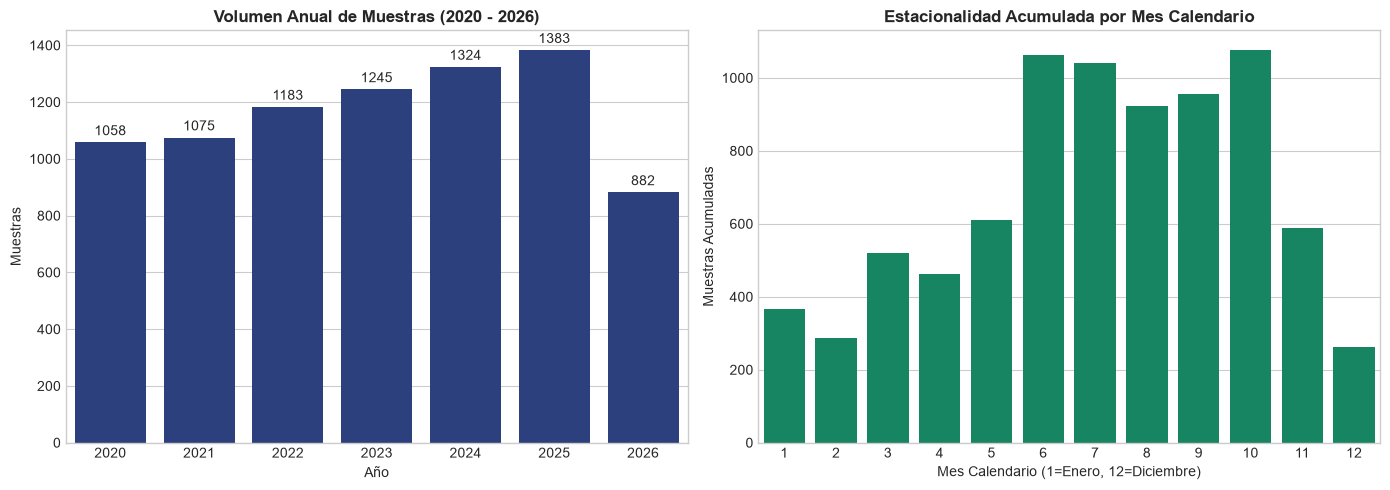

In [4]:
# 4.1 Evolución Temporal: Anual y Mensual Agregada
df_clean["anio"] = df_clean["fecha_ing_muestra"].dt.year
df_clean["mes"] = df_clean["fecha_ing_muestra"].dt.month
df_clean["anio_mes"] = df_clean["fecha_ing_muestra"].dt.to_period("M")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución Anual
yearly_counts = df_clean.groupby("anio")["id_muestra"].nunique().reset_index()
sns.barplot(data=yearly_counts, x="anio", y="id_muestra", ax=axes[0], color="#1E3A8A")
axes[0].set_title("Volumen Anual de Muestras (2020 - 2026)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Muestras")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 3), textcoords="offset points")

# Estacionalidad Mensual Acumulada
monthly_counts = df_clean.groupby("mes")["id_muestra"].nunique().reset_index()
sns.barplot(data=monthly_counts, x="mes", y="id_muestra", ax=axes[1], color="#059669")
axes[1].set_title("Estacionalidad Acumulada por Mes Calendario", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mes Calendario (1=Enero, 12=Diciembre)")
axes[1].set_ylabel("Muestras Acumuladas")

plt.tight_layout()
plt.show()


=== DISTRIBUCIÓN PARETO DE ESPECIES (TOP 10 + OTRAS) ===


,especies,total_muestras,porcentaje,pct_acumulado
0,Soja,4709,57.78,57.78
1,Trigo,1159,14.22,72.00
2,Maíz,374,4.59,76.59
3,Gatton Panic,367,4.50,81.09
4,Sorgo,246,3.02,84.11
5,Maní,217,2.66,86.77
6,Centeno,168,2.06,88.83
7,Garbanzo,107,1.31,90.14
8,Avena Blanca / Amarilla/ Byzantina,74,0.91,91.05
9,Alfalfa,72,0.88,91.93


C:\Users\Juan\AppData\Local\Temp\ipykernel_12856\1722798607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pareto_table, x="especies", y="total_muestras", palette="Blues_r")


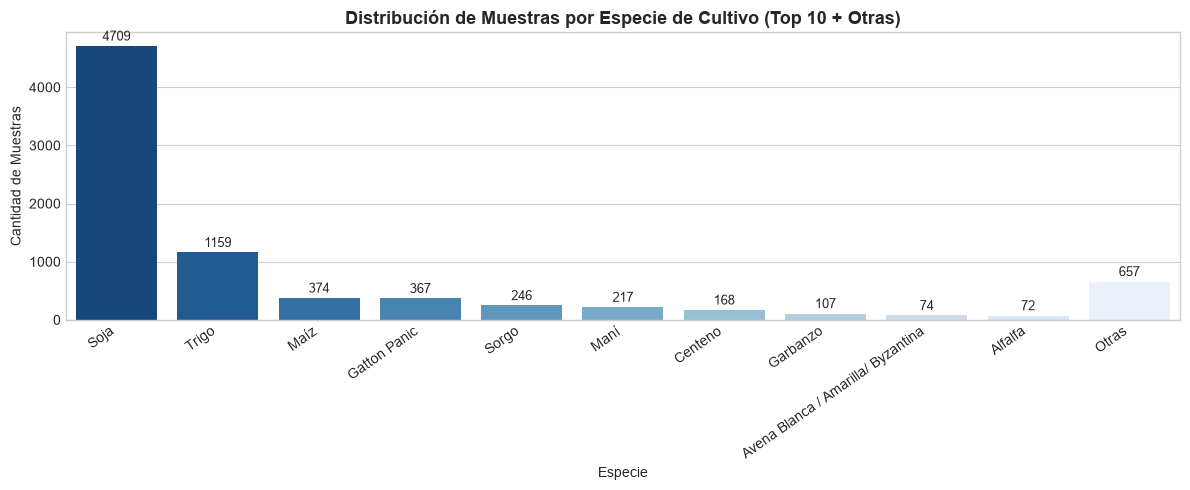

In [5]:
# 4.2 Demanda por Especie de Cultivo (Ley de Pareto: Top 10 + Otras)
crop_totals = df_clean.groupby("especies")["id_muestra"].nunique().sort_values(ascending=False).reset_index()
crop_totals.columns = ["especies", "total_muestras"]
crop_totals["porcentaje"] = (crop_totals["total_muestras"] / crop_totals["total_muestras"].sum() * 100).round(2)
crop_totals["pct_acumulado"] = crop_totals["porcentaje"].cumsum().round(2)

top_10 = crop_totals.head(10).copy()
otras_vol = crop_totals.iloc[10:]["total_muestras"].sum()
otras_row = pd.DataFrame([{
    "especies": "Otras",
    "total_muestras": otras_vol,
    "porcentaje": round(otras_vol / crop_totals["total_muestras"].sum() * 100, 2),
    "pct_acumulado": 100.0
}])
pareto_table = pd.concat([top_10, otras_row], ignore_index=True)

print("=== DISTRIBUCIÓN PARETO DE ESPECIES (TOP 10 + OTRAS) ===")
display(pareto_table)

# Gráfico de barras Pareto
plt.figure(figsize=(12, 5))
sns.barplot(data=pareto_table, x="especies", y="total_muestras", palette="Blues_r")
plt.title("Distribución de Muestras por Especie de Cultivo (Top 10 + Otras)", fontsize=13, fontweight="bold")
plt.xlabel("Especie")
plt.ylabel("Cantidad de Muestras")
plt.xticks(rotation=35, ha="right")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha="center", va="bottom", fontsize=9, xytext=(0, 2), textcoords="offset points")
plt.tight_layout()
plt.show()


C:\Users\Juan\AppData\Local\Temp\ipykernel_12856\2920779647.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lab_counts.values, y=lab_counts.index, ax=axes[0], palette="crest")
C:\Users\Juan\AppData\Local\Temp\ipykernel_12856\2920779647.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[1], palette="flare")


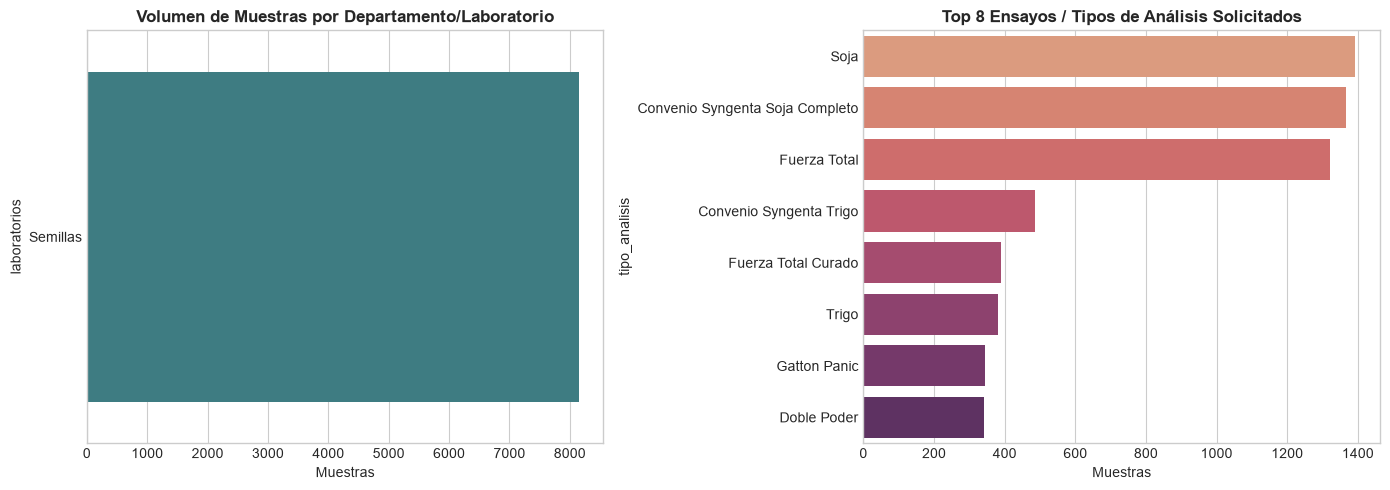

In [6]:
# 4.3 Demanda por Tipo de Análisis y Laboratorio
lab_counts = df_clean.groupby("laboratorios")["id_muestra"].nunique().sort_values(ascending=False)
tipo_counts = df_clean.groupby("tipo_analisis")["id_muestra"].nunique().sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=lab_counts.values, y=lab_counts.index, ax=axes[0], palette="crest")
axes[0].set_title("Volumen de Muestras por Departamento/Laboratorio", fontweight="bold")
axes[0].set_xlabel("Muestras")

sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[1], palette="flare")
axes[1].set_title("Top 8 Ensayos / Tipos de Análisis Solicitados", fontweight="bold")
axes[1].set_xlabel("Muestras")

plt.tight_layout()
plt.show()


---
## Fase 5: Prototipado y Validación Analítica de Requerimientos Funcionales

En esta fase se prototipan y validan formalmente los algoritmos y métricas para las tres Historias de Usuario:
- **5.1 HU-01 (RF-01)**: Listado descendente de clientes, filtros (fechas, especie, **estado activo/inactivo**) y cálculo de **Churn Estacional** (alerta ante 0% de envíos en la ventana actual vs promedio histórico).
- **5.2 HU-02 (RF-02 & RF-03)**: KPI total coincidente con la suma de tablas, Top 10 + "Otras", **serie cronológica continua de Trigo y Soja (sin baches)**, y cálculo de capacidad operativa con **alertas al 75% (Advertencia) y 90% (Saturación)**. Intervalos críticos por cultivo y tipo de análisis.
- **5.3 HU-03 (RF-04)**: Segmentación RFM con **Score de 3 dígitos (111 al 555)** por quintiles, selector de período (Ciclo 25/26 e histórico) y detección de cuentas prioritarias **"En Riesgo"** ($R \le 2 \land [F \ge 4 \lor M \ge 4]$).

### 5.1 Prototipado HU-01: Clientes Frecuentes y Churn Estacional (RF-01)

In [7]:
def get_clients_ranking_and_status(df, start_date=None, end_date=None, crop_species=None, client_status="all"):
    """
    Genera el ranking de clientes ordenado de forma descendente por volumen.
    Implementa el filtro de estado de cliente (activo / inactivo / todos).
    """
    data = df.copy()
    if crop_species and crop_species != "Todas":
        data = data[data["especies"] == crop_species]
        
    # Cartera histórica completa de clientes en el dataset filtrado
    all_clients = data[["id_cliente", "razon_social"]].drop_duplicates()
    
    # Filtrar ventana temporal
    window_data = data.copy()
    if start_date is not None:
        window_data = window_data[window_data["fecha_ing_muestra"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        window_data = window_data[window_data["fecha_ing_muestra"] <= pd.Timestamp(end_date)]
        
    # Conteo en la ventana
    window_vol = window_data.groupby("id_cliente")["id_muestra"].nunique().reset_index(name="total_muestras")
    
    # Combinar para detectar inactivos
    merged = pd.merge(all_clients, window_vol, on="id_cliente", how="left")
    merged["total_muestras"] = merged["total_muestras"].fillna(0).astype(int)
    merged["estado_cliente"] = np.where(merged["total_muestras"] > 0, "Activo", "Inactivo")
    
    total_muestras_window = merged["total_muestras"].sum()
    merged["porcentaje_total"] = (
        (merged["total_muestras"] / total_muestras_window * 100).round(2)
        if total_muestras_window > 0 else 0.0
    )
    
    # Filtrar según client_status
    if client_status in ["active", "activo"]:
        merged = merged[merged["estado_cliente"] == "Activo"]
    elif client_status in ["inactive", "inactivo"]:
        merged = merged[merged["estado_cliente"] == "Inactivo"]
        
    return merged.sort_values(by=["total_muestras", "id_cliente"], ascending=[False, True]).reset_index(drop=True)

# Demostración del ranking (Todo el período)
ranking_demo = get_clients_ranking_and_status(df_clean, client_status="all")
print("Top 10 Clientes Frecuentes:")
display(ranking_demo.head(10))
print(f"\nDistribución por Estado en la Cartera: {ranking_demo['estado_cliente'].value_counts().to_dict()}")


Top 10 Clientes Frecuentes:


,id_cliente,razon_social,total_muestras,estado_cliente,porcentaje_total
0,392,NN,2204,Activo,27.04
1,522,NN,488,Activo,5.99
2,104,NN,452,Activo,5.55
3,2795,NN,378,Activo,4.64
4,4557,NN,297,Activo,3.64
5,62,NN,284,Activo,3.48
6,1328,NN,269,Activo,3.30
7,25,NN,252,Activo,3.09
8,9261,NN,186,Activo,2.28
9,4237,NN,164,Activo,2.01



Distribución por Estado en la Cartera: {'Activo': 361}


In [8]:
# Cálculo de Alerta de Churn Estacional (0% en ventana actual vs promedio histórico mismo mes)
ref_date = df_clean["fecha_ing_muestra"].max()
current_month = ref_date.month
current_year = ref_date.year

month_data = df_clean[df_clean["fecha_ing_muestra"].dt.month == current_month]

# Volumen en el mes actual del último año
curr_vol = (
    month_data[month_data["fecha_ing_muestra"].dt.year == current_year]
    .groupby(["id_cliente", "razon_social"])["id_muestra"]
    .nunique()
    .rename("volumen_actual")
)

# Promedio histórico en ese mismo mes calendario en años anteriores
hist_data = month_data[month_data["fecha_ing_muestra"].dt.year < current_year].copy()
hist_data["year"] = hist_data["fecha_ing_muestra"].dt.year
hist_avg = (
    hist_data.groupby(["id_cliente", "razon_social", "year"])["id_muestra"]
    .nunique()
    .groupby(["id_cliente", "razon_social"])
    .mean()
    .rename("promedio_historico_mismo_mes")
)

churn_summary = pd.concat([curr_vol, hist_avg], axis=1)
churn_summary = churn_summary[churn_summary["promedio_historico_mismo_mes"].notna()].fillna(0)
churn_summary["promedio_historico_mismo_mes"] = churn_summary["promedio_historico_mismo_mes"].round(1)
churn_summary["alerta_churn_estacional"] = (
    (churn_summary["volumen_actual"] == 0) & (churn_summary["promedio_historico_mismo_mes"] > 0)
)
churn_alerts = churn_summary[churn_summary["alerta_churn_estacional"]].sort_values(
    by="promedio_historico_mismo_mes", ascending=False
).reset_index()

print(f"=== REPORTE DE CHURN ESTACIONAL (MES {current_month} - AGOSTO) ===")
print(f"Clientes en Alerta de Churn Estacional: {len(churn_alerts)}")
print(f"Muestras promedio en riesgo: {churn_alerts['promedio_historico_mismo_mes'].sum():.1f}")
display(churn_alerts.head(10))


=== REPORTE DE CHURN ESTACIONAL (MES 8 - AGOSTO) ===
Clientes en Alerta de Churn Estacional: 74
Muestras promedio en riesgo: 317.4


,id_cliente,razon_social,volumen_actual,promedio_historico_mismo_mes,alerta_churn_estacional
0,350,NN,0.0,32.0,True
1,714,NN,0.0,24.0,True
2,2795,NN,0.0,24.0,True
3,4763,NN,0.0,16.0,True
4,109,NN,0.0,14.0,True
5,4281,NN,0.0,11.7,True
6,4557,NN,0.0,11.5,True
7,38,NN,0.0,7.3,True
8,3687,NN,0.0,7.0,True
9,1856,NN,0.0,6.7,True


### 5.2 Prototipado HU-02: Cultivos, Continuidad sin Baches y Alertas de Capacidad (RF-02 & RF-03)

✓ VALIDACIÓN EXITOSA: KPI Total (8150) coincide exactamente con la Suma de la Tabla (8150).


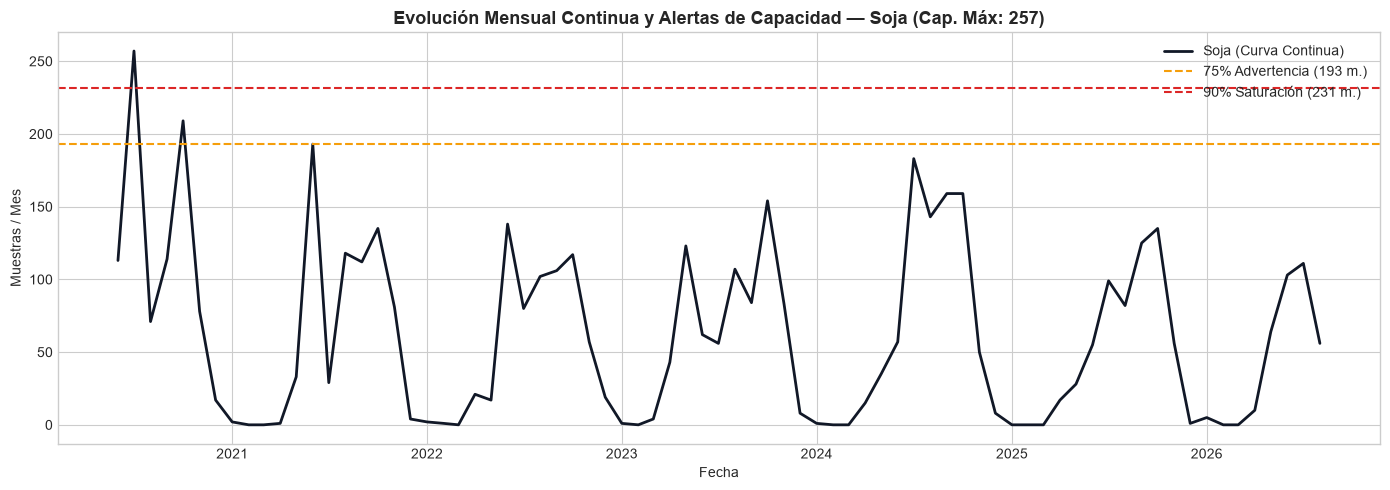

Meses en Saturación o Advertencia para Soja:


,fecha,total_muestras,pct_capacidad,estado
1,2020-07-01,257,100.0,Saturación
4,2020-10-01,209,81.3,Advertencia
12,2021-06-01,193,75.1,Advertencia


In [9]:
# Validación de coincidencia matemática: KPI Total == Suma de Tabla Top 10 + Otras
total_kpi = df_clean["id_muestra"].nunique()
table_sum = pareto_table["total_muestras"].sum()
assert total_kpi == table_sum, f"Discrepancia: KPI={total_kpi} vs Tabla={table_sum}"
print(f"✓ VALIDACIÓN EXITOSA: KPI Total ({total_kpi}) coincide exactamente con la Suma de la Tabla ({table_sum}).")

# Curva Cronológica Continua (Trigo y Soja) sin baches temporales
full_monthly_range = pd.period_range(
    df_clean["fecha_ing_muestra"].min().to_period("M"),
    df_clean["fecha_ing_muestra"].max().to_period("M"),
    freq="M"
)

def get_continuous_monthly_series(df, species_name):
    sp_data = df[df["especies"] == species_name].copy()
    sp_data["year_month"] = sp_data["fecha_ing_muestra"].dt.to_period("M")
    monthly = sp_data.groupby("year_month")["id_muestra"].nunique()
    # Reindexar con el rango completo rellenando con 0 para garantizar continuidad sin baches
    continuous = monthly.reindex(full_monthly_range, fill_value=0).reset_index()
    continuous.columns = ["year_month", "total_muestras"]
    continuous["fecha"] = continuous["year_month"].dt.to_timestamp()
    return continuous

soja_cont = get_continuous_monthly_series(df_clean, "Soja")
trigo_cont = get_continuous_monthly_series(df_clean, "Trigo")

# Alertas de Capacidad Operativa (75% Advertencia, 90% Saturación)
def evaluate_capacity(series_df, capacity_ref=None):
    if capacity_ref is None:
        capacity_ref = float(series_df["total_muestras"].max())
    df_res = series_df.copy()
    df_res["pct_capacidad"] = (df_res["total_muestras"] / capacity_ref * 100).round(1)
    conditions = [
        df_res["pct_capacidad"] >= 90,
        df_res["pct_capacidad"] >= 75
    ]
    df_res["estado"] = np.select(conditions, ["Saturación", "Advertencia"], default="Normal")
    return df_res, capacity_ref

soja_cap, cap_max_soja = evaluate_capacity(soja_cont)

# Graficar curva continua y umbrales operativos
plt.figure(figsize=(14, 5))
plt.plot(soja_cont["fecha"], soja_cont["total_muestras"], label="Soja (Curva Continua)", color="#111827", lw=2)
plt.axhline(cap_max_soja * 0.75, color="#F59E0B", linestyle="--", label=f"75% Advertencia ({cap_max_soja * 0.75:.0f} m.)")
plt.axhline(cap_max_soja * 0.90, color="#DC2626", linestyle="--", label=f"90% Saturación ({cap_max_soja * 0.90:.0f} m.)")
plt.title(f"Evolución Mensual Continua y Alertas de Capacidad — Soja (Cap. Máx: {int(cap_max_soja)})", fontsize=13, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Muestras / Mes")
plt.legend()
plt.tight_layout()
plt.show()

print("Meses en Saturación o Advertencia para Soja:")
display(soja_cap[soja_cap["estado"] != "Normal"][["fecha", "total_muestras", "pct_capacidad", "estado"]].tail(5))


In [10]:
# Intervalos Críticos de Demanda por Cultivo y Tipo de Análisis
critical_intervals = (
    df_clean[df_clean["especies"].isin(["Soja", "Trigo"])]
    .groupby(["especies", "tipo_analisis"])["id_muestra"]
    .nunique()
    .reset_index(name="total_muestras")
    .sort_values(by=["especies", "total_muestras"], ascending=[True, False])
)

print("=== INTERVALOS CRÍTICOS DE DEMANDA POR CULTIVO Y TIPO DE ANÁLISIS ===")
for crop in ["Soja", "Trigo"]:
    print(f"\n--- Top Ensayos para {crop} ---")
    sub = critical_intervals[critical_intervals["especies"] == crop].head(5)
    display(sub)


=== INTERVALOS CRÍTICOS DE DEMANDA POR CULTIVO Y TIPO DE ANÁLISIS ===

--- Top Ensayos para Soja ---


,especies,tipo_analisis,total_muestras
13,Soja,Soja,1393
4,Soja,Convenio Syngenta Soja Completo,1367
7,Soja,Fuerza Total,812
5,Soja,Doble Poder,263
8,Soja,Fuerza Total Curado,231



--- Top Ensayos para Trigo ---


,especies,tipo_analisis,total_muestras
16,Trigo,Convenio Syngenta Trigo,486
23,Trigo,Trigo,380
19,Trigo,Fuerza Total,161
17,Trigo,Doble Poder,65
15,Trigo,Calidad Trigo/Soja,32


### 5.3 Prototipado HU-03: Segmentación RFM y Alerta de Fuga de Clientes (RF-04)

In [11]:
# Exclusión de cuentas de convenio institucional (id_cliente > 50.000)
rfm_raw = df_clean[df_clean["id_cliente"] <= 50000].copy()
ref_date_rfm = rfm_raw["fecha_ing_muestra"].max()

rfm_base = rfm_raw.groupby(["id_cliente", "razon_social"]).agg(
    recencia=("fecha_ing_muestra", lambda x: (ref_date_rfm - x.max()).days),
    frecuencia=("id_muestra", "nunique"),
    valor_monetario=("importe_solicitud", "sum")
).reset_index()

# Scoring por Quintiles de 1 a 5 (uso de rank method='first' para evitar colisiones)
rfm_base["R"] = pd.qcut(rfm_base["recencia"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_base["F"] = pd.qcut(rfm_base["frecuencia"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_base["M"] = pd.qcut(rfm_base["valor_monetario"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Score de 3 dígitos (111 al 555)
rfm_base["rfm_score"] = rfm_base["R"].astype(str) + rfm_base["F"].astype(str) + rfm_base["M"].astype(str)

# Criterio 3.2: Etiquetado 'En Riesgo': Baja Recencia (R <= 2) con Alta Frecuencia (F >= 4) o Alto Valor (M >= 4)
rfm_base["en_riesgo"] = (rfm_base["R"] <= 2) & ((rfm_base["F"] >= 4) | (rfm_base["M"] >= 4))

at_risk_clients = rfm_base[rfm_base["en_riesgo"]].sort_values("valor_monetario", ascending=False).reset_index(drop=True)

print(f"=== RESULTADOS DE SEGMENTACIÓN RFM ===")
print(f"• Clientes Totales Evaluados: {len(rfm_base)}")
print(f"• Clientes Prioritarios 'En Riesgo': {len(at_risk_clients)} ({len(at_risk_clients)/len(rfm_base)*100:.1f}%)")
print(f"• Valor Económico en Riesgo: ${at_risk_clients['valor_monetario'].sum():,.2f}")
print("\nTop 5 Clientes Prioritarios para Gestión Comercial:")
display(at_risk_clients.head(5))


=== RESULTADOS DE SEGMENTACIÓN RFM ===
• Clientes Totales Evaluados: 357
• Clientes Prioritarios 'En Riesgo': 29 (8.1%)
• Valor Económico en Riesgo: $1,986,500.00

Top 5 Clientes Prioritarios para Gestión Comercial:


,id_cliente,razon_social,recencia,frecuencia,valor_monetario,R,F,M,rfm_score,en_riesgo
0,760,NN,1121,75,412400.0,2,5,5,255,True
1,4797,NN,1057,42,314400.0,2,5,5,255,True
2,33,NN,1058,5,113000.0,2,3,4,234,True
3,2065,NN,1053,15,109000.0,2,5,3,253,True
4,3,NN,1129,10,99800.0,2,4,3,243,True


---
## Fase 6: Evaluación & Exportación de Vistas Dimensionales (RD-02)

Validación final de cumplimiento con los Requerimientos de Datos (RD-02):
- **Sumatoria de muestras por cliente en ventana temporal**.
- **Conteo y participación porcentual agrupado por especie (Top 10 + Otras)**.
- **Agregación mensual por año/mes para análisis cronológico**.
- **Variables RFM por cliente** ($R, F, M$).

In [12]:
# Verificación de integridad de las agregaciones dimensionales (RD-02)
print("Resumen de datasets derivados y contratos de datos:")
print(f"1. clean_agro_data: {df_clean.shape[0]} registros limpios sin nulos en claves.")
print(f"2. pareto_species: {len(pareto_table)} registros (Top 10 + Otras) sumando {pareto_table['total_muestras'].sum()} muestras.")
print(f"3. time_series_continuous: {len(full_monthly_range)} meses continuos evaluados.")
print(f"4. rfm_mart: {len(rfm_base)} cuentas con score RFM 111-555 asignado.")
print("\n✓ Pipeline CRISP-DM completado exitosamente y listo para consumo en producción.")


Resumen de datasets derivados y contratos de datos:
1. clean_agro_data: 8150 registros limpios sin nulos en claves.
2. pareto_species: 11 registros (Top 10 + Otras) sumando 8150 muestras.
3. time_series_continuous: 75 meses continuos evaluados.
4. rfm_mart: 357 cuentas con score RFM 111-555 asignado.

✓ Pipeline CRISP-DM completado exitosamente y listo para consumo en producción.
